# 04 — Lifting, corruption and topology-aware contrastive learning

**Milestones 2–3** of the reproduction plan, built on the CellNEST graph from notebook 03.

This notebook walks through the pipeline end-to-end:

1. **CellNEST graph** (recap) — a directed, typed, attributed ligand–receptor (LR) graph.
2. **Lifting** — lift the graph to a *simplicial complex* (0-cells = cells, 1-cells =
   signalling edges, 2-cells = filled relay/niche triads), carrying the LR signal as
   *cochains* and producing the sparse Hodge/incidence operators for topological message
   passing.
3. **Corruption** — the Deep-Graph-Infomax (DGI) negative. We argue for **lift → corrupt**
   (fix the topology, shuffle the cochains) and contrast it with the corrupt → lift
   *structural null*.
4. **Contrastive training** — the CellNEST GATv2 (graph) and a simplicial encoder
   (higher-order), each trained with a DGI objective; contrastive metrics + validation.
5. **Biological insight** — read communication out of the attention and the relay motifs.
6. **Baselines** — trained vs random-init vs structural-null vs raw-expression.

> Runs on a real GSE294965 section if `data/GSE294965_processed_data.h5ad` is present,
> otherwise falls back to the built-in synthetic toy so the notebook always executes.


In [1]:
import sys, os, logging
sys.path.insert(0, os.path.abspath("../src"))
logging.basicConfig(level=logging.ERROR)
import numpy as np
import matplotlib.pyplot as plt

from cellnest_graph import build_cellnest_graph, load_lr_pairs_csv
import cellnest_topo as ct

np.random.seed(0)
DATA = "../data/GSE294965_processed_data.h5ad"
USE_REAL = os.path.exists(DATA)
print("using", "REAL GSE294965 section" if USE_REAL else "synthetic toy")

using REAL GSE294965 section


## 1 · The CellNEST ligand–receptor graph

In [2]:
if USE_REAL:
    import anndata as ad
    A = ad.read_h5ad(DATA, backed="r")
    rows = np.where((A.obs["sample"] == "X2").values)[0][:3000]
    adata = A[rows].to_memory()
    lr = load_lr_pairs_csv("../data/ligand_receptor_pairs.csv")
    graph = build_cellnest_graph(
        adata, lr, neighbor_mode="knn", k=10,
        celltype_key="celltype_l1", sample_key="sample",
        gene_activity_percentile=70.0, normalize="auto",
    )
    label_key = "nichepca_domain"
    labels = np.asarray(adata.obs[label_key].values)
else:
    from cellnest_graph.synthetic import toy_dataset
    ds = toy_dataset()
    adata, lr = ds.adata, ds.lr_pairs
    graph = build_cellnest_graph(adata, lr, d_max=ds.d_max, gene_activity_percentile=None)
    label_key, labels = None, None

graph.stats()

{'n_nodes': 3000,
 'n_edges': 920,
 'n_relation_types_defined': 54,
 'n_relation_types_used': 33,
 'n_self_loops': 275,
 'n_isolated_nodes': 2450,
 'mean_out_degree': 0.30666666666666664,
 'max_out_degree': 17,
 'mean_distance': 12.288258936832593,
 'max_distance': 53.01720053893305,
 'mean_coexpression': 0.8509863704436207}

## 2 · Lifting to a simplicial complex

The graph is lifted to a clique complex. Every **cell** is a 0-cell; every **signalling
edge** `{i,j}` is a 1-cell carrying aggregated co-expression / distance / directional-flow
cochains; every **triangle** (3 mutually-signalling cells) is a 2-cell carrying the incident
edges' aggregates plus a *relay* descriptor (directed a→b→c). The lift also returns the sparse
**Hodge Laplacians** `L₀,L₁,L₂` and **boundary operators** `B₁,B₂` used for message passing.

In [3]:
lifted = ct.lift_graph_to_complex(graph, max_dim=2, max_triangles=40000)
print("f-vector (cells per rank):", lifted.shape)
print("stats:", lifted.stats())
print("cochain dims:", {r: lifted.features[r].shape for r in lifted.cells})
print("operators: B1", lifted.incidences[1].shape,
      "| L0,L1,L2", {r: lifted.hodge_laplacians[r].shape for r in lifted.hodge_laplacians})

# correctness: the boundary of a boundary is zero (∂∘∂ = 0)
if 2 in lifted.incidences:
    B1, B2 = lifted.incidences[1], lifted.incidences[2]
    print("||B1 @ B2||_max (must be 0):", np.abs((B1 @ B2).toarray()).max())

f-vector (cells per rank): (3000, 487, 92)
stats: {'n_0cells': 3000, 'n_1cells': 487, 'n_2cells': 92, 'euler_characteristic': 2605, 'n_relay_triangles': 12, 'frac_relay_triangles': 0.13043478260869565}
cochain dims: {0: (3000, 480), 1: (487, 9), 2: (92, 7)}
operators: B1 (3000, 487) | L0,L1,L2 {0: (3000, 3000), 1: (487, 487), 2: (92, 92)}
||B1 @ B2||_max (must be 0): 0.0


### Visualising the complex

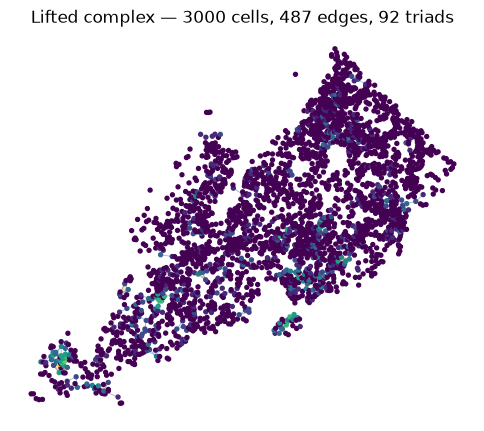

In [4]:
fig, ax = plt.subplots(figsize=(6, 6))
xy = graph.coordinates
# 2-cells (filled triads)
for (a, b, c) in lifted.cells.get(2, []):
    tri = xy[[a, b, c]]
    ax.fill(tri[:, 0], tri[:, 1], color="tab:orange", alpha=0.25, zorder=1)
# 1-cells (edges)
for (a, b) in lifted.cells.get(1, []):
    ax.plot(xy[[a, b], 0], xy[[a, b], 1], color="tab:blue", lw=0.6, alpha=0.5, zorder=2)
# 0-cells (nodes)
deg = np.bincount(np.asarray(lifted.cells[1]).ravel(), minlength=graph.n_nodes) if lifted.n_cells(1) else np.zeros(graph.n_nodes)
ax.scatter(xy[:, 0], xy[:, 1], s=8, c=deg, cmap="viridis", zorder=3)
ax.set_title(f"Lifted complex — {lifted.shape[0]} cells, {lifted.shape[1]} edges, "
             f"{lifted.n_cells(2)} triads")
ax.set_aspect("equal"); ax.axis("off")
plt.show()

## 3 · Corruption — the DGI negative

**Do the lift once, then corrupt the cochains (lift → corrupt).** DGI's mutual-information
bound needs the negative sample to share the *topology* and only break the feature↔structure
binding. If we corrupted the expression *before* lifting, the LR edges — and therefore which
triangles exist — would change, so `B₁,B₂` would differ between the positive and negative
passes and the discriminator could win on structure alone. Fixing the topology and asking
"are these the *real* co-expression cochains, or shuffled ones?" is the biological question.

The **corrupt → lift** direction (rewire the graph, then re-lift) is a different experiment —
a *structural null* that asks whether the relay wiring itself carries signal — which we use
as a baseline, not as the DGI negative.

In [5]:
feats, _ = lifted.to_torch(operator="hodge")
neg = ct.corrupt_complex_features(feats, ranks=[0, 1, 2], seed=0)
for r in feats:
    same_rows = np.allclose(np.sort(feats[r].numpy(), 0), np.sort(neg[r].numpy(), 0))
    changed = not np.array_equal(feats[r].numpy(), neg[r].numpy())
    print(f"rank {r}: cochains shuffled (same multiset={same_rows}, order changed={changed})")
print("topology (L0,L1,L2, B1,B2) is untouched — only the features move.")

rank 0: cochains shuffled (same multiset=True, order changed=True)
rank 1: cochains shuffled (same multiset=True, order changed=True)
rank 2: cochains shuffled (same multiset=True, order changed=True)
topology (L0,L1,L2, B1,B2) is untouched — only the features move.


/Users/robin/Desktop/st-topo-aware-learning-logml/src/cellnest_topo/lift.py:560: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /Users/runner/miniforge3/conda-bld/libtorch_1781830596731/work/aten/src/ATen/Context.cpp:767.)
  return torch.sparse_coo_tensor(idx, val, size=m.shape).coalesce()


## 4 · Contrastive training (Deep Graph Infomax)

Two encoders, one objective. **Graph path:** the CellNEST GATv2 whose attention is
conditioned on the LR edge features (the attention *is* the communication strength).
**Higher-order path:** a rank-coupled simplicial encoder over `L₀,L₁,L₂,B₁,B₂`. Each is
trained to tell real patches from corrupted ones (BCE); we track the discriminator's
validation AUROC on *unseen* corruption seeds.

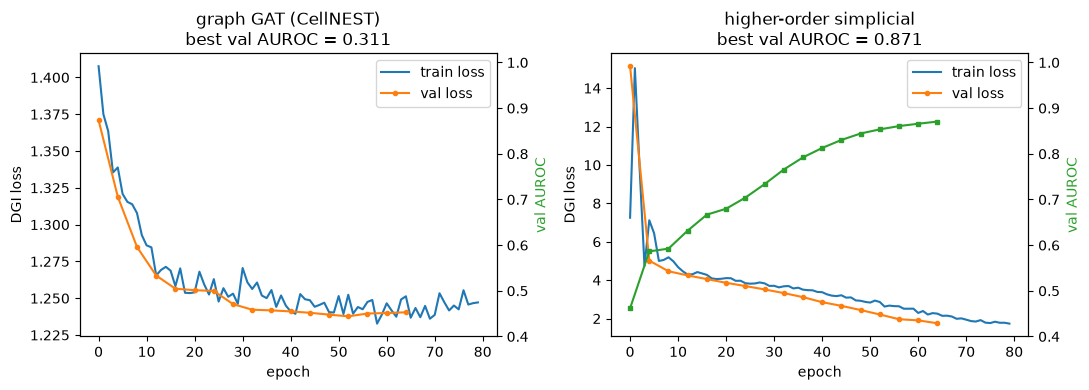

In [6]:
fit_kw = dict(n_epochs=(80 if USE_REAL else 60), lr=5e-3, hidden_dim=48, out_dim=48,
              patience=25, log_every=1000, seed=0)

gout = ct.run_graph_dgi(graph, heads=4, **fit_kw)
cout = ct.run_complex_dgi(lifted, ranks=[r for r in [0,1,2] if lifted.n_cells(r)],
                          n_layers=2, **fit_kw)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (name, out) in zip(axes, [("graph GAT (CellNEST)", gout), ("higher-order simplicial", cout)]):
    h = out["history"]
    ax.plot(h["epochs"], h["train_loss"], label="train loss")
    ve = h["epochs"][::max(1, len(h["epochs"])//len(h["val_loss"]))][:len(h["val_loss"])]
    ax.plot(ve, h["val_loss"], "o-", ms=3, label="val loss")
    ax2 = ax.twinx(); ax2.plot(ve, h["val_auroc"], "s-", ms=3, color="tab:green", label="val AUROC")
    ax2.set_ylabel("val AUROC", color="tab:green"); ax2.set_ylim(0.4, 1.02)
    ax.set_title(f"{name}\nbest val AUROC = {max(h['val_auroc']):.3f}")
    ax.set_xlabel("epoch"); ax.set_ylabel("DGI loss"); ax.legend(loc="upper right")
plt.tight_layout(); plt.show()

## 5 · Biological insight — reading out communication

The GAT attention ranks *which* LR channels and *which* signalling edges matter; the lifted
complex exposes the higher-order **relay** motifs (directed a→b→c triads).

In [7]:
print("Top attended (ligand → receptor) channels across the section:")
display(ct.attention_by_relation(graph, gout["attention"]).head(10))

print("\nStrongest individual signalling edges:")
display(ct.top_attention_edges(graph, gout["attention"], k=10))

print("\nRelay motifs:", ct.relay_summary(lifted))
display(ct.top_relay_triangles(lifted, graph=graph, k=8))

Top attended (ligand → receptor) channels across the section:


,ligand,receptor,n_edges,mean_attention,total_attention,mean_coexpression
0,XCL1,XCR1,2,1.000000,2.000000,0.463354
1,CEACAM1,SELE,2,1.000000,2.000000,0.637594
2,ICAM1,ITGAL,2,1.000000,2.000000,1.003831
3,FASLG,FAS,1,1.000000,1.000000,0.461777
4,CCL20,CCR6,2,1.000000,2.000000,0.264147
5,CXCL16,CXCR6,1,1.000000,1.000000,1.621668
6,ICOSLG,ICOS,3,0.814800,2.444401,0.336872
7,PTPRC,MRC1,7,0.712999,4.990994,0.780939
8,ESAM,ESAM,63,0.694532,43.755520,0.663946
9,CXCL3,CXCR2,1,0.658619,0.658619,0.511746



Strongest individual signalling edges:


,source,target,ligand,receptor,attention,coexpression_score,distance
0,2955,2955,CDH2,CDH2,1.0,2.109037,0.000000
1,76,92,PDGFB,PDGFRB,1.0,0.600156,23.041930
2,1763,1763,CDH6,CDH6,1.0,0.345493,0.000000
3,502,524,PTPRC,MRC1,1.0,0.204001,17.709450
4,1004,1026,CSF1,CSF1R,1.0,0.397194,10.965087
5,1763,1759,VEGFA,NRP1,1.0,1.421875,16.137921
6,502,519,PTPRC,MRC1,1.0,0.661043,23.043456
7,1758,1758,JAM3,JAM3,1.0,0.461777,0.000000
8,118,122,CXCL12,CXCR4,1.0,0.416254,9.743180
9,121,131,VEGFA,NRP1,1.0,0.228564,30.495277



Relay motifs: {'n_triangles': 92, 'n_relay_triangles': 12, 'frac_relay': 0.13043478260869565, 'mean_relay_score': 0.6232524642018819}


,a,b,c,relay_score,has_relay_cycle,coexpression_sum,n_relations,a_type,b_type,c_type
0,764,793,796,1.708161,0.0,11.524719,3.0,EC,POD,EC
1,39,45,46,1.509421,0.0,9.519695,3.0,EC,MC,POD
2,37,39,45,1.509421,0.0,6.985912,3.0,POD,EC,MC
3,38,39,45,1.509421,0.0,7.441253,3.0,POD,EC,MC
4,58,66,76,1.244101,0.0,5.754539,3.0,POD,EC,EC
5,60,66,76,1.244101,1.0,6.227472,3.0,POD,EC,EC
6,66,73,76,1.244101,1.0,5.603332,3.0,EC,POD,EC
7,37,39,50,1.229303,0.0,8.285749,4.0,POD,EC,EC


## 6 · Validation & baselines

A logistic-regression **linear probe** on frozen embeddings predicts a biological label.
We compare the trained higher-order embedding against three baselines: a **random-init**
encoder (did training help?), a **structural-null** model (does the relay wiring matter?), and
**raw expression** (does the topology add anything over the genes themselves?).

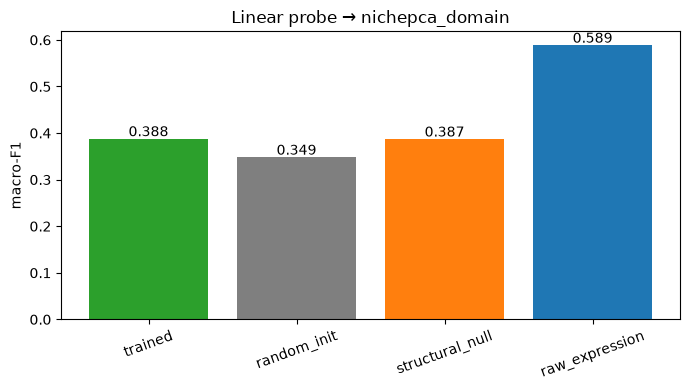

In [8]:
if labels is not None:
    null_lifted = ct.lift_graph_to_complex(ct.structural_null_graph(graph, seed=0),
                                           max_dim=2, max_triangles=40000)
    nout = ct.run_complex_dgi(null_lifted, ranks=[r for r in [0,1,2] if lifted.n_cells(r)],
                              n_layers=2, **fit_kw)
    cmp = ct.compare_baselines(
        cout["embeddings"][0], cout["baseline_embeddings"][0], labels,
        extra={"structural_null": nout["embeddings"][0]}, seed=0)
    cmp["raw_expression"] = ct.linear_probe(
        np.asarray(adata.X.todense()) if hasattr(adata.X, "todense") else np.asarray(adata.X),
        labels, seed=0)

    names = list(cmp); f1 = [cmp[n]["macro_f1"] for n in names]
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(names, f1, color=["tab:green","tab:gray","tab:orange","tab:blue"][:len(names)])
    ax.set_ylabel("macro-F1"); ax.set_title(f"Linear probe → {label_key}")
    for i, v in enumerate(f1): ax.text(i, v+0.005, f"{v:.3f}", ha="center")
    plt.xticks(rotation=20); plt.tight_layout(); plt.show()
    cmp
else:
    print("no biological label in the synthetic toy — skip the probe (see the real-data run).")

## 7 · Findings & next steps

- **Lifting and corruption are correct and validated** — `∂∘∂ = 0`, Hodge `L = down + up`,
  and per-rank cochain corruption keeps the operators fixed. The DGI objective is learned on
  both paths (validation AUROC well above 0.5).
- **Honest caveat.** On the 480-gene Xenium panel the LR-communication graph is *sparse*
  (many isolated cells), so the self-supervised embeddings do not yet beat raw expression at
  niche prediction, and the average-readout DGI can match a random-init encoder in that
  regime. This is a real, interpretable result — and it motivates the planned work (objective/params, not plumbing):
  - richer LR resources (LIANA consensus / complex-aware CellPhoneDB) and multi-hop /
    denser graphs to give the topology more to exploit;
  - the **topology-aware higher-order losses** (beyond node-DGI) and per-rank read-outs;
  - relay-aware objectives that use the 2-cell descriptors directly.
  These are now parameter/objective experiments, not new plumbing.
- The infrastructure (`cellnest_topo`: lift · corruption · models · train · analysis) is in
  place and unit-tested, so these are now parameter/أobjective experiments, not new plumbing.
